In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [2]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
fig_name_prefix = 'link_descarga'
file_ext = '.png'
dpi_value = 200
include_title = True

Shape of data:  (369, 22)


# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación, ¿cuál de las siguientes opciones creés que es la correcta?

In [ ]:
# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

result = result.reindex(["No sabemos\nsi es seguro", "Seguros.\nVerificados\npor personas", "No sé", "Si es de mis\ncontactos\nes seguro", "Seguros.\nVerificados\npor filtro\ninteligente"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nPor escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Mármol elige un 10% más "No sabemos si es seguro" y "verificados por personas"
* Mantovani elige 10% más "No se" y "Si es de mis contactos es seguro". 

In [ ]:
# Con misconception vs Sin Misconception - Agrupando No se - link para descargar
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\nsi es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(fig_name_prefix + '_misco_agregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En ambos colegios vemos "Sin misconception" por encima de con misconception por primera vez

In [ ]:
# Con misconception vs Sin Misconception - Desagrupando No se - Link para descargar
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\nVerificados\npor personas') |
                               (result.index == 'Seguros.\nVerificados\npor filtro\ninteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\ncontactos\nes seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Si es de mis\ncontactos\nes seguro",
                                2: "No sé",
                                3: "No sabemos\nsi es seguro"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions fuertes por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Modelo marmol con mas misconceptions que el mantovani
* El mantovani elige mas la misconception debil
* EL mantovani elige mas No se
* El modelo Marmol elige mas la respuesta sin miscon

                            Totales  Modelo Mármol  Juan Mantovani
Con\nmisconception        44.986450      46.206897       44.196429
No sé                     17.073171      10.344828       21.428571
No sabemos\nsi es seguro  37.940379      43.448276       34.375000


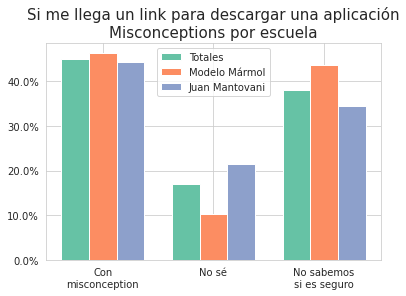

In [5]:
# Con misconception vs Sin Misconception - Desagrupando No se - Link para descargar
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "No sabemos\nsi es seguro"}).transpose()

print(result*100)

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

In [ ]:
# Si me llega un link para descargar una aplicación - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

result = result.reindex(["No sabemos\nsi es seguro", "Seguros.\nVerificados\npor personas", "No sé", "Si es de mis\ncontactos\nes seguro", "Seguros.\nVerificados\npor filtro\ninteligente"])

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nPor grado", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Modelo Mármol: 6to elige un 10% menos "No sabemos si es seguro" y un 5% más "Verificados por personas"
* Mantovani: De 4to a 6to sube un 20% "No sabemos si es seguro", baja un 10% la opción "No sé" y un 10% "Verificados por filtro inteligente"

In [ ]:
# Con misconception vs Sin Misconception - Agrupando No se - link para descargar  - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\nsi es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(fig_name_prefix + '_misco_agregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* EN el modelo en 6to grado aumentan misconceptions
* En el mantovani reducen misconceptions

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\nVerificados\npor personas') |
                               (result.index == 'Seguros.\nVerificados\npor filtro\ninteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\ncontactos\nes seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Si es de mis\ncontactos\nes seguro",
                                2: "No sé",
                                3: "No sabemos\nsi es seguro"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions fuertes por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Modelo: Sexto tiene un 10% mas de respuestas con misconc fuertes, elige menos la rta con misconc debil, eligen mas No se y 10% menos la rta sin misc
* Mantovani: En grados mas altos bajan misconceptions, bajan no se y aumentan la rta sin misconc. Un lujo

                          Quinto Mármol  Sexto Mármol  Cuarto Mantovani  \
Con\nmisconception            42.857143     48.780488         46.987952   
No sé                          7.936508     12.195122         26.506024   
No sabemos\nsi es seguro      49.206349     39.024390         26.506024   

                          Quinto Mantovani  Sexto Mantovani  
Con\nmisconception                   46.25        37.704918  
No sé                                20.00        16.393443  
No sabemos\nsi es seguro             33.75        45.901639  


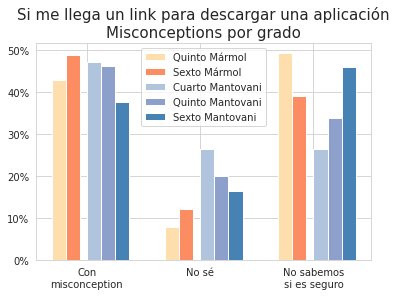

In [10]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "No sabemos\nsi es seguro"}).transpose()

print(result*100)

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

In [ ]:
# Si me llega un link para descargar una aplicación - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

result = result.reindex(["No sabemos\nsi es seguro", "Seguros.\nVerificados\npor personas", "No sé", "Si es de mis\ncontactos\nes seguro", "Seguros.\nVerificados\npor filtro\ninteligente"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nPor género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* No hay muchas diferencias en el Mármol, las chicas eligen un 5% más la opción "Verificados por personas", y los varones un 5% más "Verificados por filtro inteligente"
* En el Mantovani las chicas eligen un 15% más "Si es de mis contactos es seguro" y los varones un 5% más "Verificados por filtro inteligente"

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\nsi es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(fig_name_prefix + '_misco_agregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* No hay grandes diferencias. Las chicas eligen levemente mas las respuestas con misconc.

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\nVerificados\npor personas') |
                               (result.index == 'Seguros.\nVerificados\npor filtro\ninteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\ncontactos\nes seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Si es de mis\ncontactos\nes seguro",
                                2: "No sé",
                                3: "No sabemos\nsi es seguro"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions fuertes por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el modelo no hay grandes diferencias
* En el mantovani las chicas eligen menos rtas con misc fuertes. Eligen mas la misc debil, y levemente menos la rta sin misc.

                          Masculino Mármol  Femenino Mármol  \
Con\nmisconception               45.333333        47.142857   
No sé                            12.000000         8.571429   
No sabemos\nsi es seguro         42.666667        44.285714   

                          Masculino Mantovani  Femenino Mantovani  
Con\nmisconception                  41.666667           45.918367  
No sé                               21.666667           22.448980  
No sabemos\nsi es seguro            36.666667           31.632653  


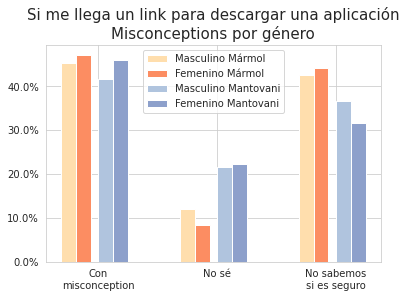

In [9]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\nsi es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\nVerificados\npor personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\ncontactos\nes seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\npor filtro\ninteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\nsi es seguro')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\nsi es seguro'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "No sabemos\nsi es seguro"}).transpose()

print(result*100)

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Si me llega un link para descargar una aplicación\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)